In [36]:
import pandas as pd

data = pd.read_csv("dataset.csv")

In [37]:
data.head()

,text,language
0,How are you?,English
1,I am fine,English
2,What is your name?,English
3,Where are you going?,English
4,This is a good day,English


In [38]:
data.columns

Index(['text', 'language'], dtype='object')

In [39]:
print("Total Rows:", len(data))

Total Rows: 150


In [40]:
import string


data = data.dropna(subset=['text'])


data['text'] = data['text'].astype(str)


def preprocess(text):
  text = text.lower()
  text = text.translate(str.maketrans('', '', string.punctuation))
  return text

data['text'] = data['text'].apply(preprocess)


data = data[data['text'] !=""]

print("Clean samples:", len(data))


Clean samples: 150


In [41]:
print(data['text'].head(10))

0                              how are you
1                                i am fine
2                        what is your name
3                      where are you going
4                       this is a good day
5                       i love programming
6              machine learning is amazing
7    artificial intelligence is the future
8                     i am learning python
9              this project is interesting
Name: text, dtype: object


In [42]:
print(data.head(10))
print(data.columns)

                                    text language
0                            how are you  English
1                              i am fine  English
2                      what is your name  English
3                    where are you going  English
4                     this is a good day  English
5                     i love programming  English
6            machine learning is amazing  English
7  artificial intelligence is the future  English
8                   i am learning python  English
9            this project is interesting  English
Index(['text', 'language'], dtype='object')


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [45]:
X = data['text']
y = data['language']

vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2,4))
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2,random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:", classification_report(y_test, y_pred))
print("\nConfusion Matrix:", confusion_matrix(y_test,y_pred))

Accuracy: 0.8

Classification Report:               precision    recall  f1-score   support

     English       0.80      0.67      0.73         6
      French       1.00      0.50      0.67         8
      German       0.67      1.00      0.80         4
     Spanish       0.62      1.00      0.77         5
        Urdu       1.00      1.00      1.00         7

    accuracy                           0.80        30
   macro avg       0.82      0.83      0.79        30
weighted avg       0.85      0.80      0.79        30


Confusion Matrix: [[4 0 1 1 0]
 [1 4 1 2 0]
 [0 0 4 0 0]
 [0 0 0 5 0]
 [0 0 0 0 7]]


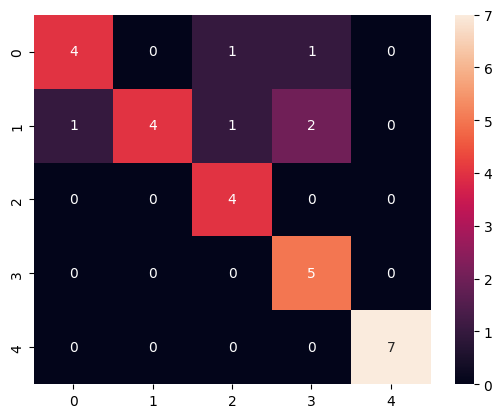

In [46]:
import seaborn as sns

sns = sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)


In [47]:
import joblib

joblib.dump(model, 'model.pk1')
joblib.dump(vectorizer, 'vectorizer.pk1')

print("Model Saved")

Model Saved


In [48]:
def predict_language(text):
  text = preprocess(text)
  vec = vectorizer.transform([text])
  pred = model.predict(vec)[0]
  return pred


In [49]:
print(predict_language("Hello World"))

English


In [50]:
print(predict_language("آپ کیسے ہیں؟"))

Urdu


In [51]:
print(predict_language("Das ist schÃ¶n"))

German
